In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap

In [3]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [4]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

# Method 1 - lat lon bins of equal area (uniform lon and uniform sin lat) sample geographically

In [5]:
# Sample bins uniformly (geographically)
def sample_bins(df, n_lon_bins=72, n_lat_bins=9):
    # Define area of interest (Arctic Ocean)
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Assign each point to a bin
    df['lon_bin'] = pd.cut(df['Longitude_[deg_E]'], bins=lon_bins, labels=False, include_lowest=True)
    df['lat_bin'] = pd.cut(df['Latitude_[deg_N]'], bins=lat_bins, labels=False, include_lowest=True)    
    
    # Find bin with least data points and sample that many points from each bin
    min_count = df.groupby(['lon_bin', 'lat_bin']).size().min()
    sampled_df = df.groupby(['lon_bin', 'lat_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)
    return sampled_df


In [6]:
df_sampled = sample_bins(df_ST, n_lon_bins=144, n_lat_bins=18)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_10893/3332530918.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(['lon_bin', 'lat_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)


In [7]:
def plot_heatmap(ds_cleaned, n_lon_bins=72, n_lat_bins=9, bin_max=None):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    resolution = 'l'

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Compute max depth per bin
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1
    H = np.zeros((n_lon, n_lat))

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > H[li, lj]:
                H[li, lj] = depth_vals[i]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Draw sine-lat bin edges as lightgrey lines
    # Latitude lines (at each lat_bins edge)
    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Longitude lines (at each lon_bins edge)
    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Plot data on top
    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    m.pcolormesh(X_map, Y_map, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Redraw coastlines on top of pcolormesh
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin')

    plt.show()
    print(f'bin max={bin_max}')

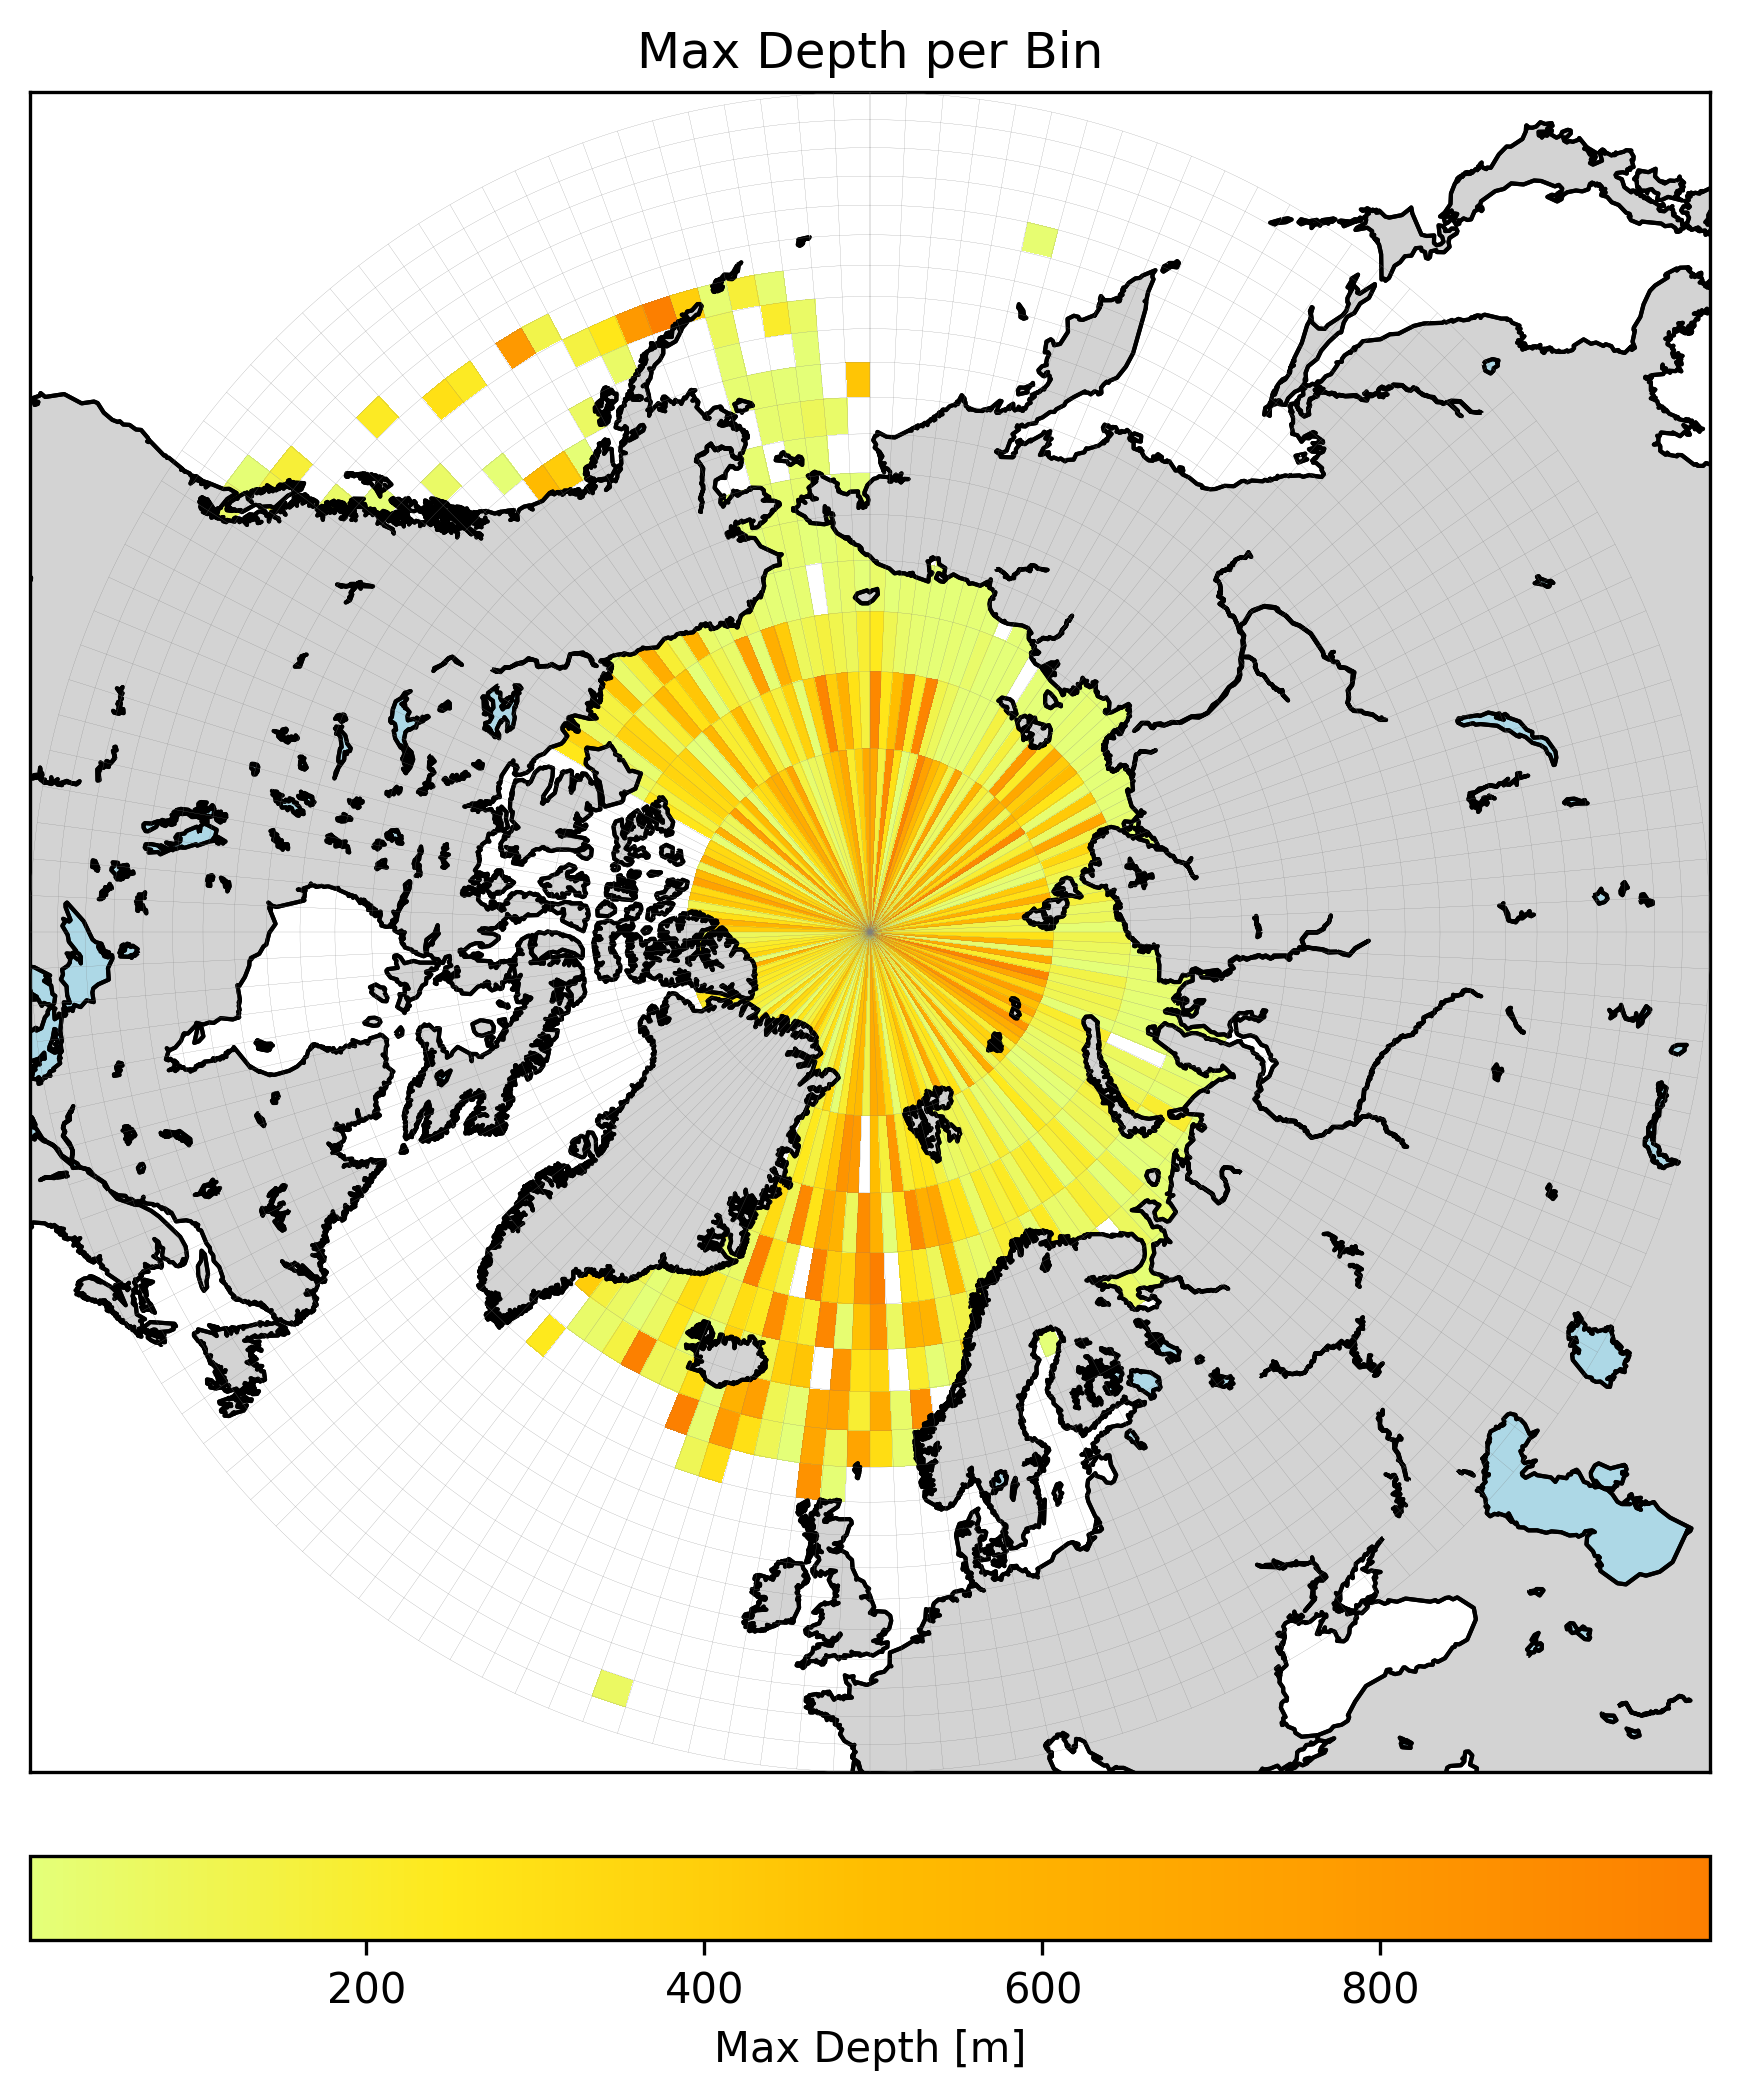

bin max=995.0


In [8]:
plot_heatmap(df_sampled, n_lon_bins=144, n_lat_bins=18)

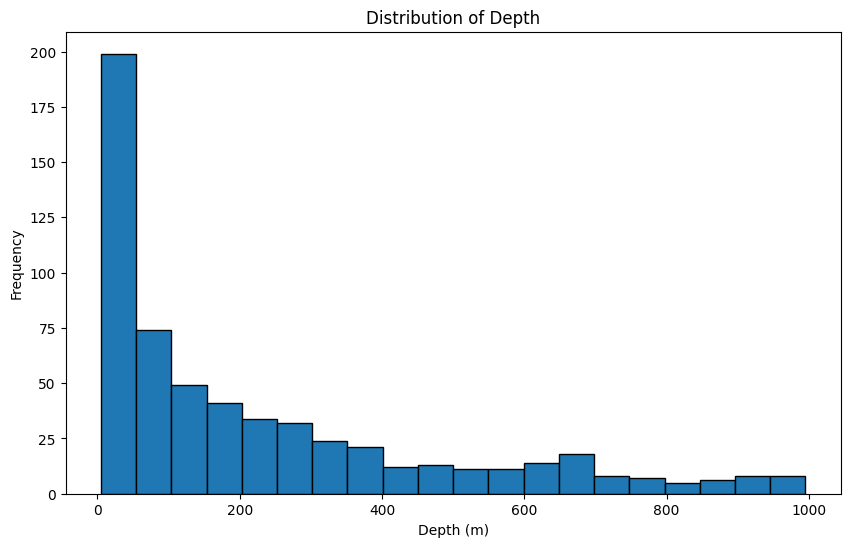

In [9]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_sampled['Depth_[m]'], bins=20, edgecolor='black')
plt.title('Distribution of Depth')
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.show()

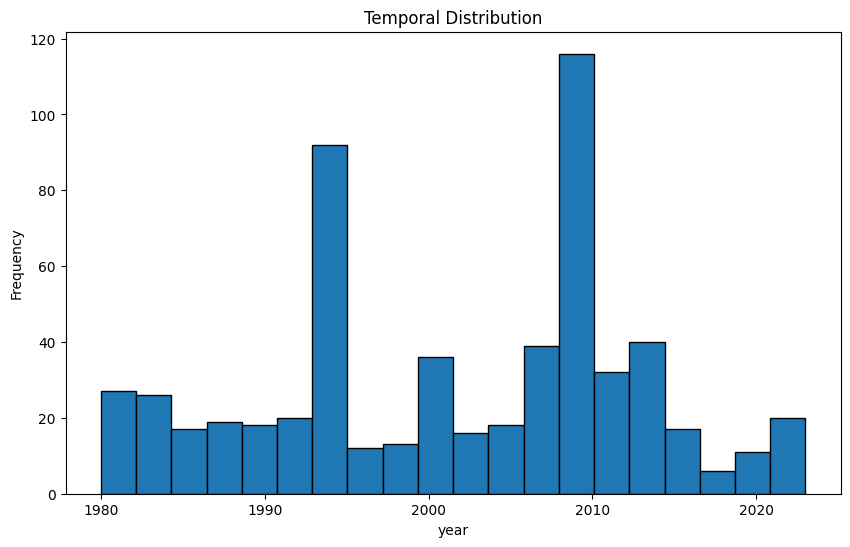

In [10]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_sampled['year'], bins=20, edgecolor='black')
plt.title('Temporal Distribution')
plt.xlabel('year')
plt.ylabel('Frequency')
plt.show()

# Method 2 - lat lon bins of equal area (uniform lon and uniform sin lat) and divide each bin into 10 depth bins sample geographically and vertically

In [11]:
# Sample bins of bins (geographical and depth bins)
def sample_bins_of_bins(df, n_lon_bins=72, n_lat_bins=9, n_depth_bins=5):
    # Define area of interest (Arctic Ocean)
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))
    depth_bins = np.linspace(df['Depth_[m]'].min(), df['Depth_[m]'].max(), n_depth_bins + 1)

    # Assign each point to a bin
    df['lon_bin'] = pd.cut(df['Longitude_[deg_E]'], bins=lon_bins, labels=False, include_lowest=True)
    df['lat_bin'] = pd.cut(df['Latitude_[deg_N]'], bins=lat_bins, labels=False, include_lowest=True)
    df['depth_bin'] = pd.cut(df['Depth_[m]'], bins=depth_bins, labels=False, include_lowest=True)
    
    # Find bin with least data points and sample that many points from each bin
    min_count = df.groupby(['lon_bin', 'lat_bin','depth_bin']).size().min()
    sampled_df = df.groupby(['lon_bin', 'lat_bin','depth_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)
    return sampled_df


In [12]:
df_sampled = sample_bins_of_bins(df_ST, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_10893/3563306100.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(['lon_bin', 'lat_bin','depth_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)


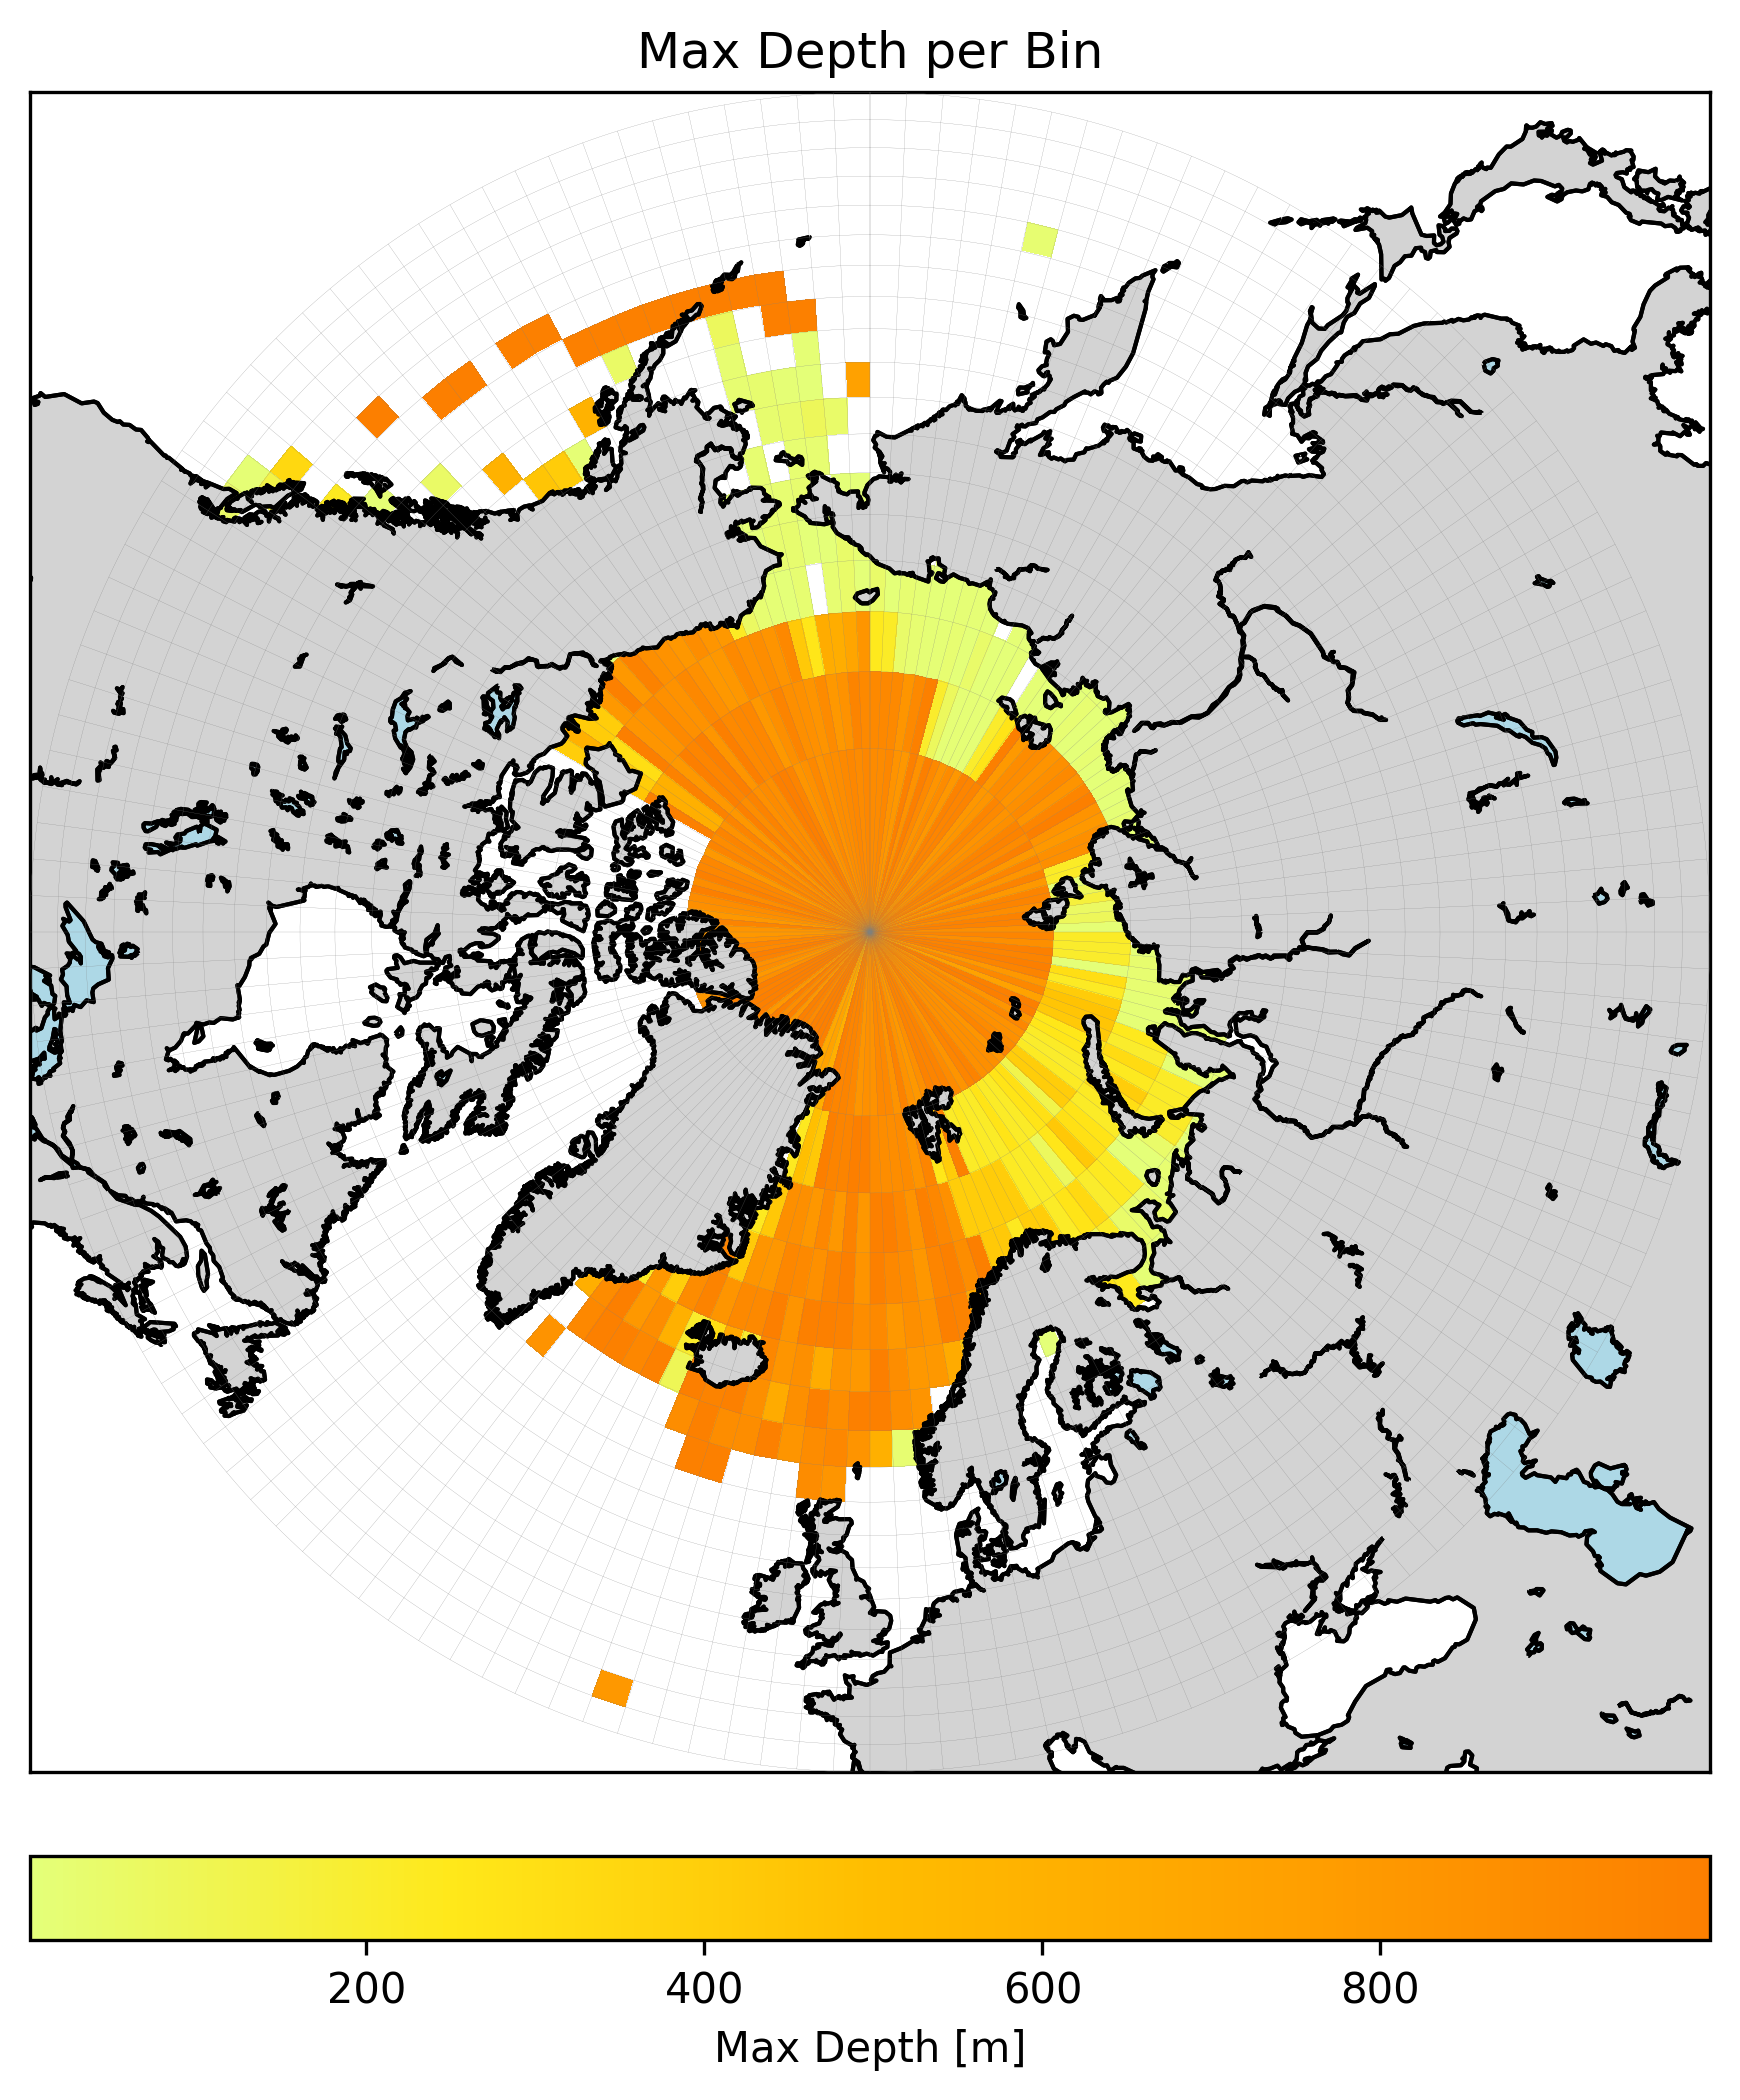

bin max=995.0


In [13]:
plot_heatmap(df_sampled, n_lon_bins=144, n_lat_bins=18)

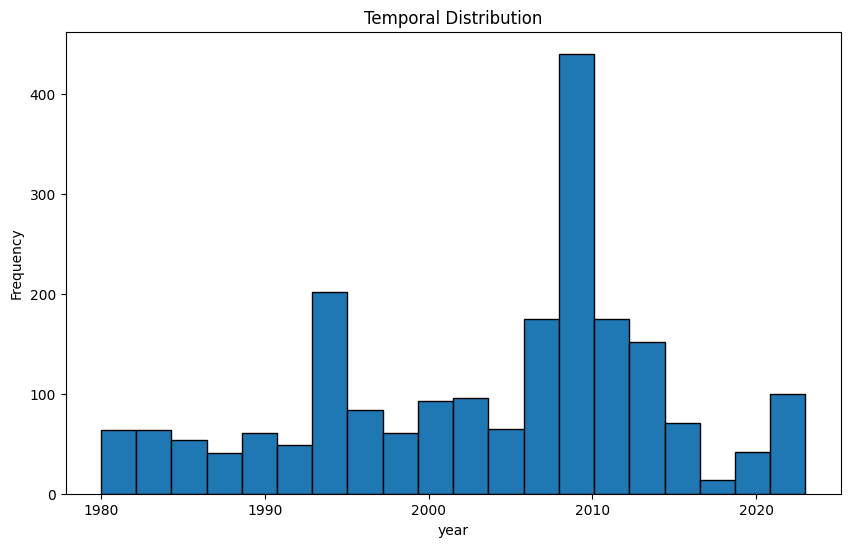

In [14]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_sampled['year'], bins=20, edgecolor='black')
plt.title('Temporal Distribution')
plt.xlabel('year')
plt.ylabel('Frequency')
plt.show()

# Method 3 - lat lon bins of equal area (uniform lon and uniform sin lat) and divide each bin into 5 depth bins sample geographically and vertically, divide dataset into first 20 years and last 23 years sample separately and combine after

In [15]:
df_sampled_0 = sample_bins_of_bins(df_80_00, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)
df_sampled_1 = sample_bins_of_bins(df_00_23, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_10893/3563306100.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lon_bin'] = pd.cut(df['Longitude_[deg_E]'], bins=lon_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_10893/3563306100.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lat_bin'] = pd.cut(df['Latitude_[deg_N]'], bins=lat_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_

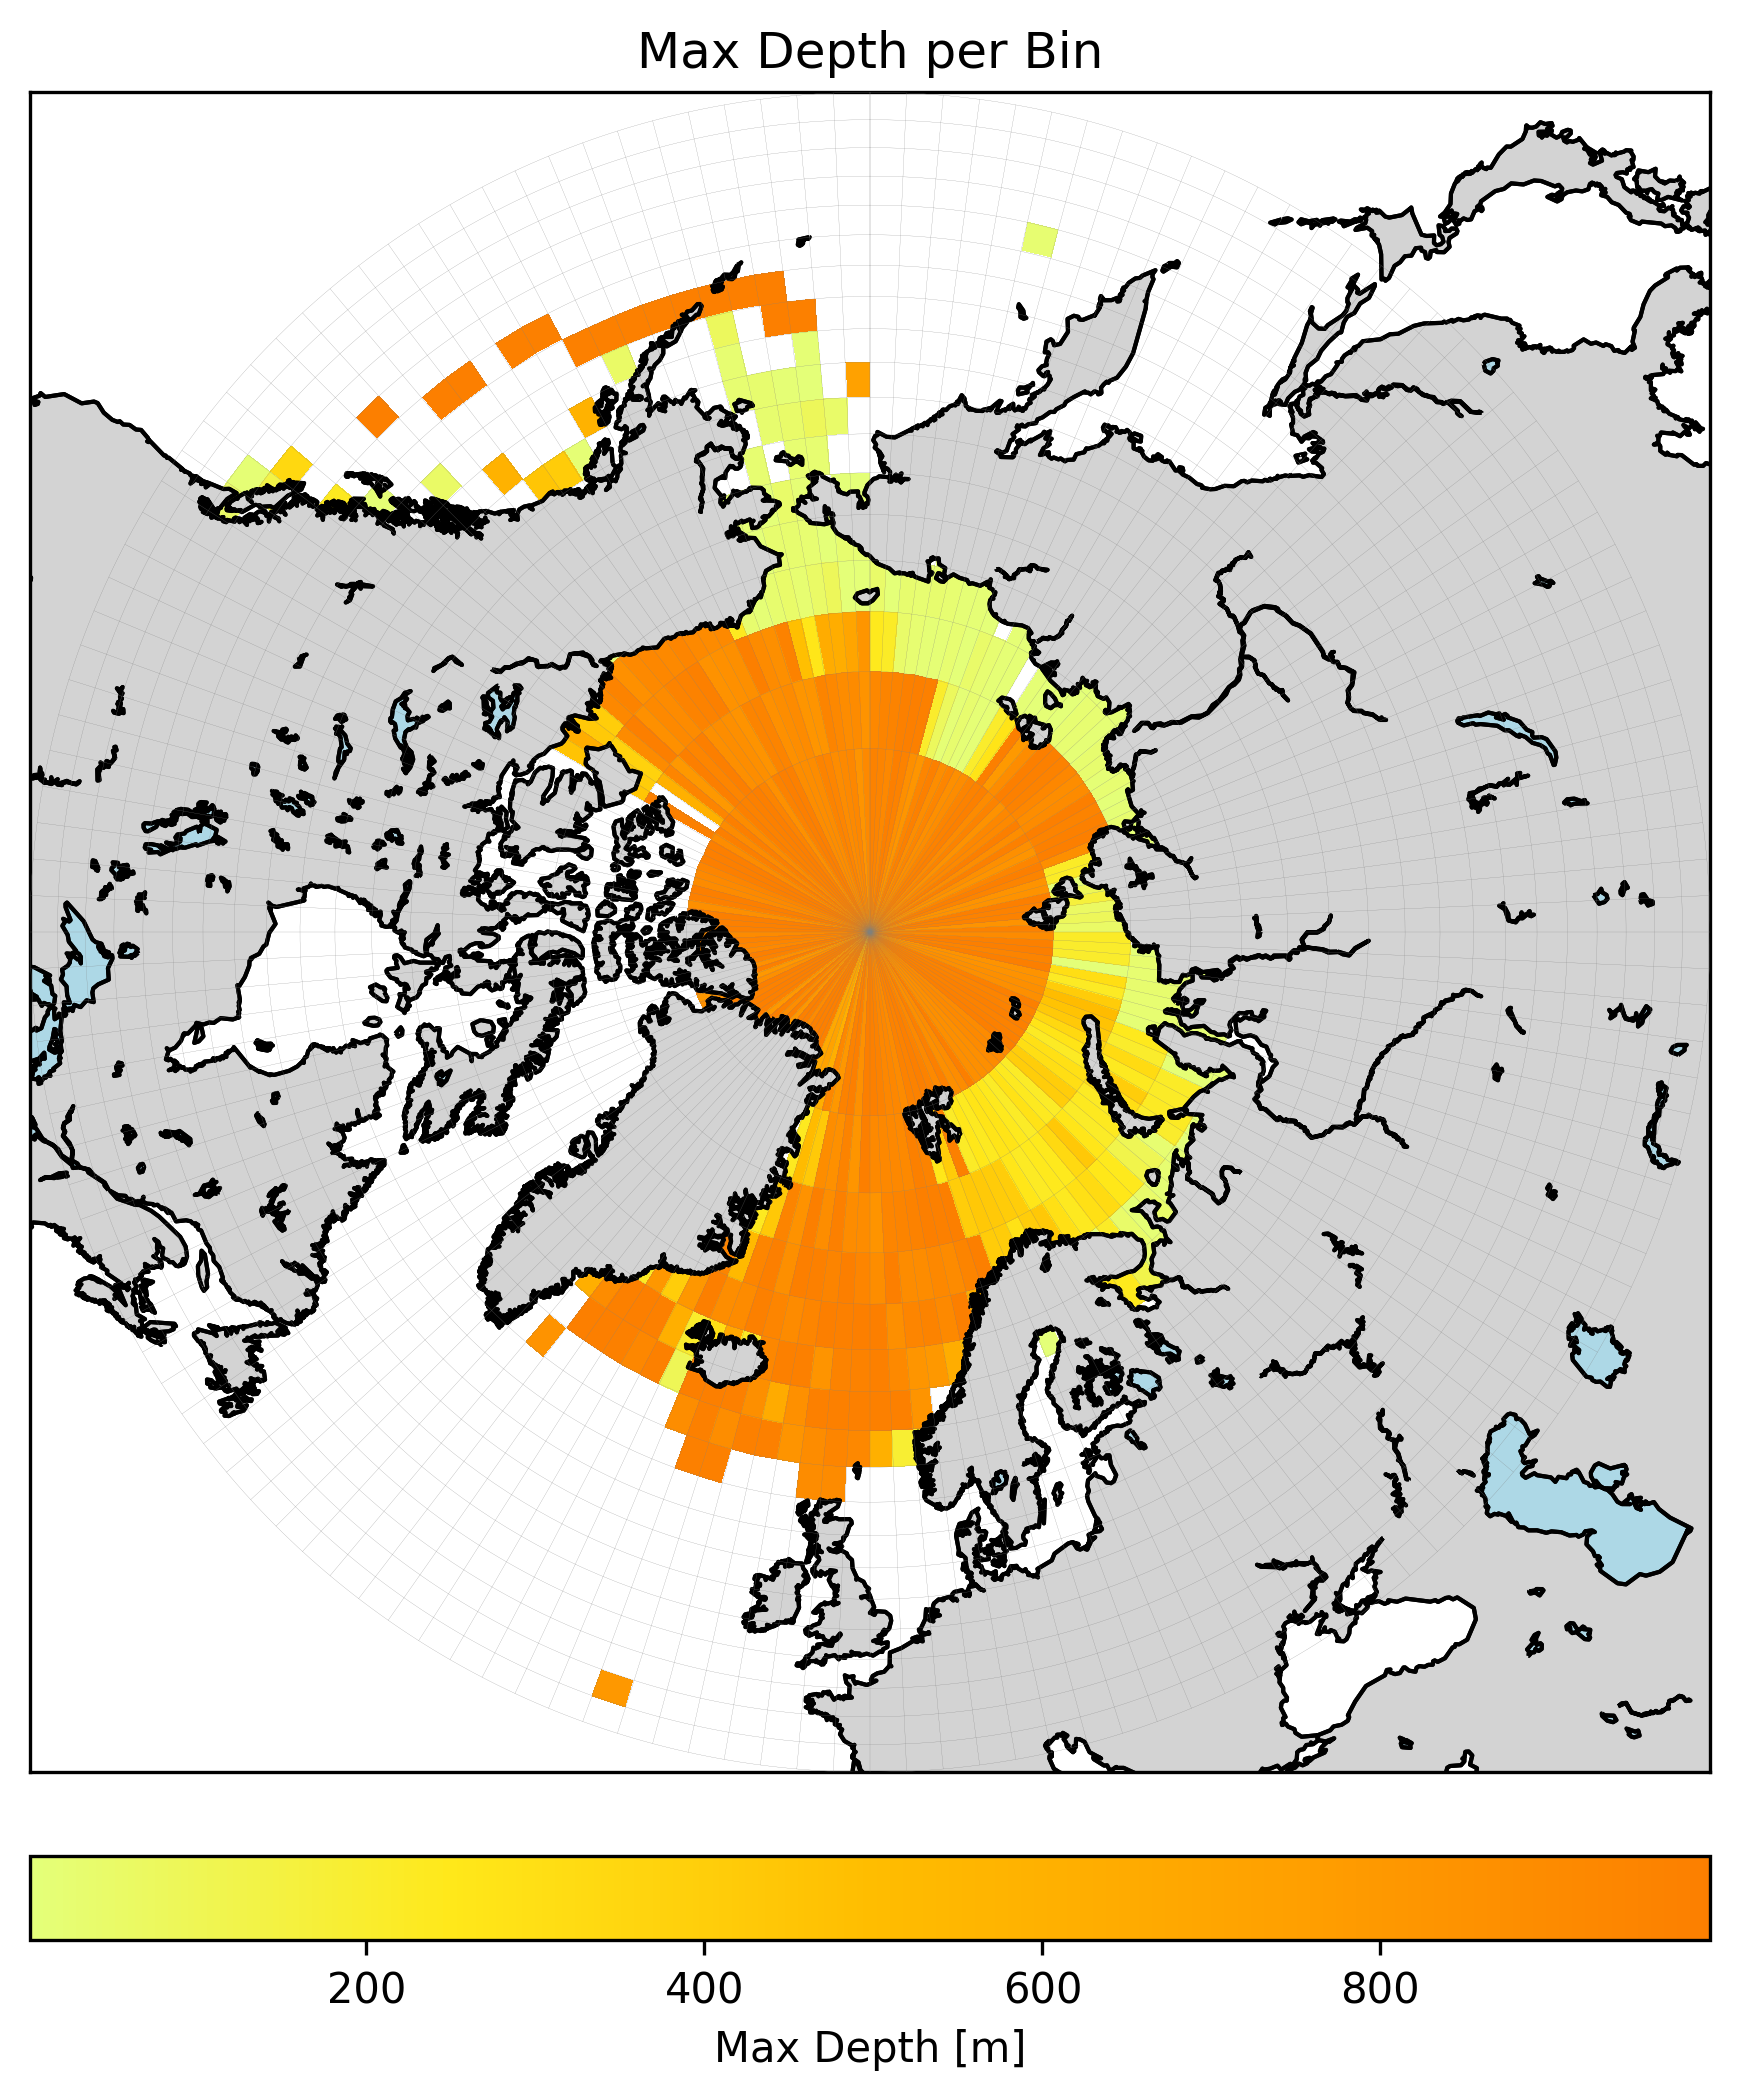

bin max=995.0


In [16]:
plot_heatmap(df_sampled, n_lon_bins=144, n_lat_bins=18)

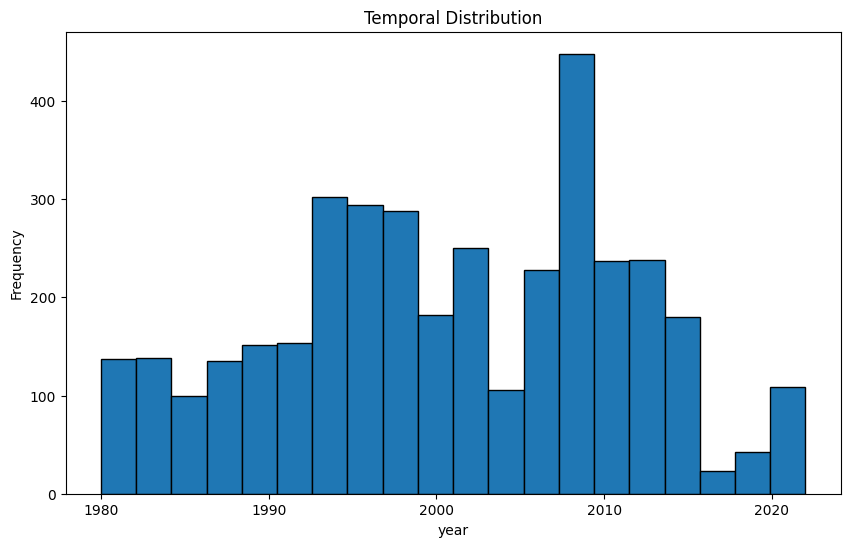

In [17]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_sampled['year'], bins=20, edgecolor='black')
plt.title('Temporal Distribution')
plt.xlabel('year')
plt.ylabel('Frequency')
plt.show()

# Method 4 - lat lon bins of equal area (uniform lon and uniform sin lat) and divide each bin into 5 depth bins sample geographically and vertically, divide dataset into 4 decadal bins, sample separately and combine after

In [18]:
# Divide dataset into 4 decades (1980-1990, 1990-2000, 2000-2010, 2010-2023)
df_80_90 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 1990)]
df_90_00 = df_ST[(df_ST['year'] >= 1990) & (df_ST['year'] < 2000)]
df_00_10 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2010)]
df_10_23 = df_ST[(df_ST['year'] >= 2010) & (df_ST['year'] < 2023)]

In [ ]:
# Sample bins of bins (geographical and depth bins) for each decade
df_sampled_0 = sample_bins_of_bins(df_80_90, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)
df_sampled_1 = sample_bins_of_bins(df_90_00, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)
df_sampled_2 = sample_bins_of_bins(df_00_10, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)
df_sampled_3 = sample_bins_of_bins(df_10_23, n_lon_bins=144, n_lat_bins=18, n_depth_bins=5)

# Concatenate sampled dataframes for all decades
df_sampled = pd.concat([df_sampled_0, df_sampled_1, df_sampled_2, df_sampled_3], ignore_index=True)